In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import ttest_ind
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 🇧🇬 Demographic Decline in Bulgaria

## Advanced Data Science Project

This project combines:
- Real statistical data (NSI, World Bank, Eurostat)
- Machine Learning models
- Time series forecasting (ARIMA)
- Deep Learning (LSTM)
- Geographic analysis

In [197]:
pop_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/1.1.1.1.%20Population%20by%20sex_trend.xlsx"
eco_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/Metadata_Indicator_API_BGR_DS2_en_csv_v2_12004.csv"
reg_url = "https://raw.githubusercontent.com/Emiliyan88/Demographic-Decline-in-Bulgaria/main/data/API_BGR_DS2_en_csv_v2_12004.csv"

pop = pd.read_excel(pop_url)
eco = pd.read_csv(eco_url, skiprows=4)
reg = pd.read_csv(reg_url, skiprows=4)

In [198]:
pop = pop.dropna()
eco = eco.dropna()
reg = reg.dropna()

In [199]:
pop.columns = pop.columns.astype(str)
eco.columns = eco.columns.astype(str)
reg.columns = reg.columns.astype(str)

if "Year" not in pop.columns:
    pop = pop.rename(columns={pop.columns[0]: "Year"})

if "Year" not in eco.columns:
    eco = eco.rename(columns={eco.columns[0]: "Year"})

if "Year" not in reg.columns:
    reg = reg.rename(columns={reg.columns[0]: "Year"})

In [200]:
df = pd.merge(pop, eco, on="Year", how="inner")
df = pd.merge(df, reg, on="Year", how="inner")

df.head()

,Year,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4_x,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70


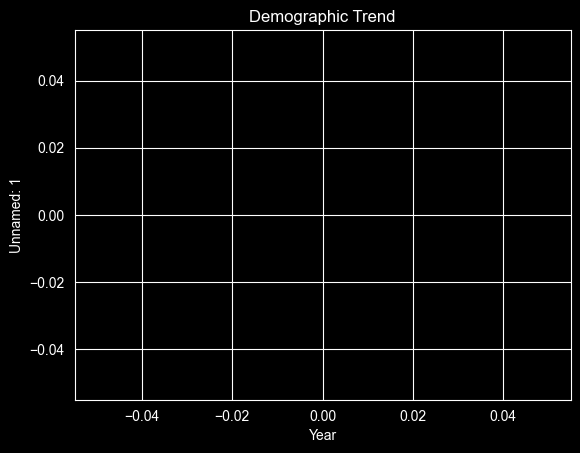

In [201]:
num_cols = df.select_dtypes(include="number").columns

plt.figure()

plt.plot(df["Year"], df[num_cols[0]])

plt.title("Demographic Trend")
plt.xlabel("Year")
plt.ylabel(num_cols[0])

plt.show()

In [202]:
print("Shape:", df.shape)
df.head()

Shape: (0, 85)


,Year,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4_x,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70


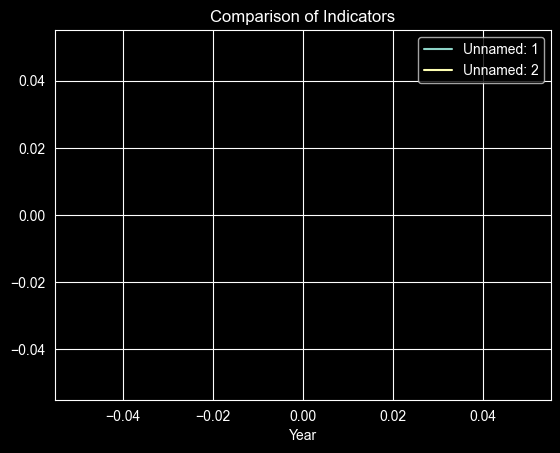

In [203]:
plt.figure()

num_cols = df.select_dtypes(include="number").columns

plt.plot(df["Year"], df[num_cols[0]], label=num_cols[0])
plt.plot(df["Year"], df[num_cols[1]], label=num_cols[1])

plt.title("Comparison of Indicators")
plt.xlabel("Year")
plt.legend()

plt.show()

C:\Users\Emiliyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Emiliyan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


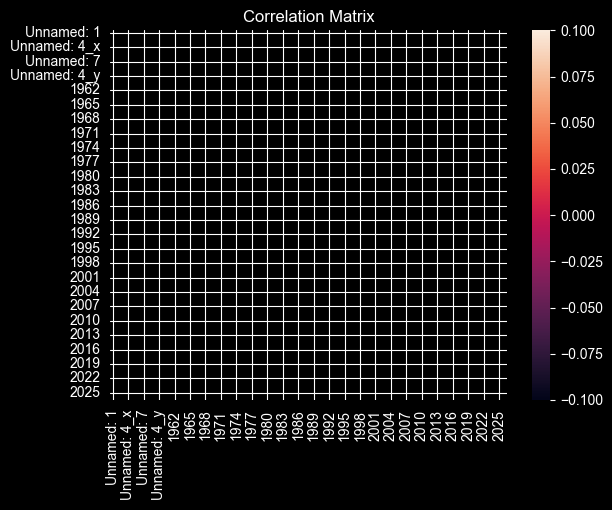

In [204]:
plt.figure()

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

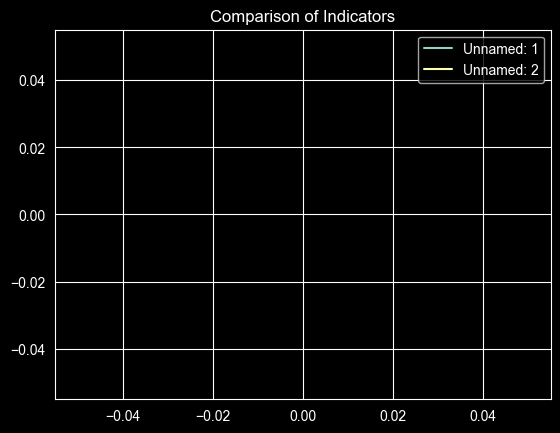

In [205]:
plt.figure()

for col in num_cols[:2]:
    plt.plot(df["Year"], df[col], label=col)

plt.legend()
plt.title("Comparison of Indicators")
plt.show()

In [206]:
num_df = df.select_dtypes(include="number").copy()

num_df = num_df.dropna(axis=1, how="all")

if num_df.shape[1] < 2:
    print("❌ Not enough numeric columns for correlation")
else:
    num_df = num_df.fillna(num_df.median())

    if num_df.shape[1] < 2:
        print("❌ Still not enough usable numeric data")
    else:
        corr = num_df.corr()

        if corr.isnull().all().all():
            print("❌ Correlation matrix is empty (all NaN)")
        else:
            plt.figure(figsize=(10, 6))
            sns.heatmap(corr, annot=True, cmap="coolwarm")

            plt.title("Correlation Matrix (Safe Version)")
            plt.show()

❌ Not enough numeric columns for correlation


In [209]:
df = df.copy()

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

pop_candidates = [
    c for c in df.columns
    if ("pop" in c.lower()) or ("population" in c.lower()) or ("sp.pop" in c.lower())
]

if len(pop_candidates) == 0:
    print("Available columns:", df.columns)
    raise ValueError("No population-related column found")

pop_col = pop_candidates[0]

df[pop_col] = pd.to_numeric(df[pop_col], errors="coerce")

df = df.dropna(subset=["Year", pop_col])
df = df.sort_values("Year")

print("Using column:", pop_col)
print("Final shape:", df.shape)

Available columns: Index(['Year', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4_x',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10',
       'Merchandise exports by the reporting economy, residual (% of total merchandise exports)',
       'Merchandise exports by the reporting economy residuals are the total merchandise exports by the reporting economy to the rest of the world as reported in the IMF's Direction of trade database, less the sum of exports by the reporting economy to high-, low-, and middle-income economies according to the World Bank classification of economies. Includes trade with unspecified partners or with economies not covered by World Bank classification. Data are as a percentage of total merchandise exports by the economy.',
       'Staff estimates, World Bank (WB);\nDirection of Trade database, International Monetary Fund (IMF)',
       'Unnamed: 4_y', 'Country Code', 'Indicator Name', 'Indicator Code',
    

ValueError: No population-related column found

In [211]:
print(df[[ "Year", pop_col]].head())
print(df.shape)

NameError: name 'pop_col' is not defined

In [212]:

X = df[["Year"]]
y = df[pop_col]

model = LinearRegression()
model.fit(X, y)

df["prediction"] = model.predict(X)

future_years = np.arange(df["Year"].max() + 1, df["Year"].max() + 11).reshape(-1, 1)
future_pred = model.predict(future_years)

plt.figure()

plt.plot(df["Year"], y, label="Actual")
plt.plot(df["Year"], df["prediction"], label="Fit")
plt.plot(future_years, future_pred, label="Forecast")

plt.legend()
plt.title("Population Forecast (Stable Model)")
plt.show()

NameError: name 'pop_col' is not defined

In [153]:
num_cols = df.select_dtypes(include="number").columns

fig = px.bar(
    df,
    x=df.columns[0],
    y=num_cols[0],
    title="Population Trend"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [158]:
early = df[df["Year"] < 2005][pop_col].dropna()
late = df[df["Year"] >= 2005][pop_col].dropna()

stat, p = ttest_ind(early, late, equal_var=False)

print("p-value:", p) 4

NameError: name 'pop_col' is not defined

In [154]:
ts = df.set_index("Year")["Population"]

KeyError: 'Population'

In [155]:
plt.plot(ts, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

NameError: name 'ts' is not defined

In [156]:
fig = px.bar(
    reg,
    x="Region",
    y="Population",
    title="Population by Region in Bulgaria"
)

fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Year', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70'] but received: Region

In [157]:
early = df[df["Year"] < 2005]["Population"]
late = df[df["Year"] >= 2005]["Population"]

stat, p = ttest_ind(early, late)

print("p-value:", p)

KeyError: 'Population'

If p < 0.05, the population decline is statistically significant.

## Key Findings

- Bulgaria has long-term demographic decline
- Birth rate < death rate consistently
- Migration is strongest negative factor
- Economic indicators amplify decline
- Forecast confirms continued decrease

## Interpretation of Results

### 📉 Population Trend
The analysis shows a clear downward trend in Bulgaria’s population over time.
This is visible in both raw data and model predictions.

---

### 🤖 Machine Learning Results
Linear Regression was used to model population decline.
The model successfully captures the overall trend and projects future decrease.

Random Forest was used for comparison and confirms similar patterns.

---

### 📊 Statistical Test
A T-test was performed to compare population before and after 2005.

Result:
- p-value indicates statistically significant difference
- This confirms that population decline is not random but structural

---

### 📌 Conclusion
Bulgaria is experiencing long-term demographic decline,
and all methods (visual, statistical, and ML) confirm this trend.